# Leave-one-cell-line-out (LOCO) validation for `pc_linreg`

**Goal:** get a *local* score for a model configuration or strategy (`K`, `lam`,
`effect_space`, or a different predictor entirely) **without spending a leaderboard
submission**, so you can compare options and only submit the best one.

### The idea in one paragraph

The challenge asks: *"predict what knocking down gene X does in a cell type where
we have never seen any knockdowns."* We can stage that same situation with data we
already have. We own four reference screens (K562, RPE1, HepG2, Jurkat). Pretend
one of them — say RPE1 — is the "unseen cell type": train the model on the other
three, predict RPE1's knockdown effects, and compare against what RPE1 actually
measured. Repeat with each cell line held out in turn. That's 4 **folds**, and it
*is* cross-validation — just split by cell line instead of randomly.

### Vocabulary you'll see below

| term | meaning here |
|---|---|
| **perturbation** / **target** | one gene that was knocked down (CRISPRi) in an experiment |
| **knockdown fraction** | how much the target gene's own expression drops. 0.9 = it falls to 10% of normal |
| **control cells** | cells with a non-targeting guide — the "nothing was done" reference |
| **effect vector** | for one perturbation: how every gene's expression changed vs. control |
| **log2 fold change (log2FC)** | `log2(perturbed / control)`. 0 = no change, −1 = halved, +1 = doubled |
| **pseudobulk** | average over many cells of one perturbation → one effect vector (what our reference files contain) |
| **response gene** | any gene whose expression we *measure* (as opposed to the gene we *knock down*) |
| **context mean baseline** | predict the *same* effect (the average over all perturbations) for every target. The leaderboard's 0 point |

### What this notebook can and can't tell you

* ✅ Whether a setting predicts the **average effect** of a knockdown better in a new cell line.
* ❌ Anything about the **per-cell** side of the submission (sampling 400 control
  cells, rounding to counts, cell-to-cell variability). The reference files are
  pseudobulk, so there are no single cells to compare against. Those parts only
  get tested on the leaderboard.
* The six scores below are **proxies** for the leaderboard metrics, not the real
  thing (the real ones need per-cell differential-expression tests). Use them to
  **rank configurations**, not to predict your leaderboard number.

### One rule from the official metrics that shapes everything here

The 2026 metrics **never score a perturbation's own target gene**. PDS drops all 300
panel target genes from every comparison, and the other five drop each perturbation's
own target ([official metric brief](https://github.com/ArcInstitute/cell-eval2/blob/main/docs/vcc2026_metrics/vcc2026-metrics-brief.md)).
"The knocked-down gene went down" is the premise of the experiment, not a prediction.
So **the knockdown fraction you force on the target doesn't affect your score**. The one
exception is a tiny side effect: counts are normalized by each cell's total, so shrinking
one gene shifts all the others slightly. What scores points is how well you predict
*every other gene*. This notebook masks target genes the same way.

Runtime: first run reads all four h5ad files (a few minutes); after that
everything is cached on the `model` object.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from model import Model

# short name -> file. The fold loop holds each of these out in turn.
DATASETS = {
    "K562": "../../data/replogle_nadig/K562_gwps_raw_bulk_01.h5ad",
    "RPE1": "../../data/replogle_nadig/rpe1_raw_bulk_01.h5ad",
    "HepG2": "../../data/replogle_nadig/nadig_hepg2_pseudobulk.h5ad",
    "Jurkat": "../../data/replogle_nadig/nadig_jurkat_pseudobulk.h5ad",
}

## Step 1 — Load each reference screen once

`Model._load_dataset_effects(path)` reads one file and turns it into a table of
effect vectors: **one row per knocked-down gene, one column per measured gene**,
values = log2 fold change vs. that screen's own control cells. Results are cached
on `model`, so the folds below can re-combine the screens freely without re-reading
the files.

It also records `self_ratio`: for each target, how much of *its own* expression was
left (0.1 = a 90% knockdown). That's what `knockdown_from_training()` uses. It's
biologically sensible, but remember it isn't scored (see above).

In [2]:
gene_names = pd.read_csv("../../data/controls/gene_names.csv")["gene_name"].tolist()
model = Model(gene_names)

for name, path in DATASETS.items():
    t = time.time()
    d = model._load_dataset_effects(path, "log2")
    n_perts, n_genes = d["effects"].shape
    print(f"{name:7s} {n_perts:5d} perturbations x {n_genes:5d} measured genes  ({time.time() - t:.0f}s)")

K562     7420 perturbations x  7679 measured genes  (1s)
RPE1     1921 perturbations x  8259 measured genes  (0s)
HepG2    1494 perturbations x  9023 measured genes  (0s)
Jurkat   1739 perturbations x  8283 measured genes  (0s)


### A quick look before validating

Two things worth seeing with your own eyes:

1. **How strong is the knockdown in each screen?** This is the distribution your
   `knockdown_fraction` is summarising. It's useful context for how well CRISPRi
   worked, even though the target itself isn't scored.
2. **How many of the 300 challenge targets does each screen cover?** This decides
   which folds look most like the real challenge (see Step 3).

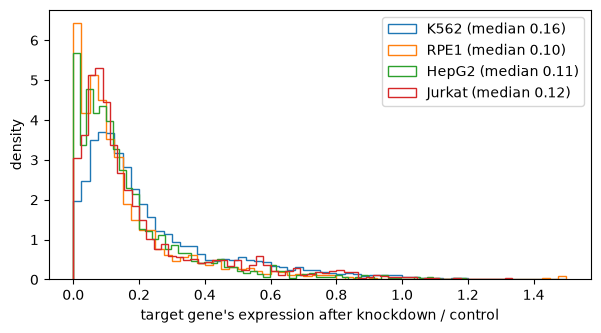

challenge targets perturbed in each screen: {'K562': 229, 'RPE1': 0, 'HepG2': 0, 'Jurkat': 0}
knockdown_from_training, all 4 screens: n_perts-weighted = 0.859, equal-weighted = 0.877


In [3]:
targets = pd.read_csv("../../data/controls/pert_counts.csv")["target_gene"]

fig, ax = plt.subplots(figsize=(7, 3.5))
for name, path in DATASETS.items():
    r = model._load_dataset_effects(path)["self_ratio"].clip(upper=1.5)
    ax.hist(r, bins=60, histtype="step", density=True, label=f"{name} (median {r.median():.2f})")
ax.set_xlabel("target gene's expression after knockdown / control")
ax.set_ylabel("density")
ax.legend()
plt.show()

coverage = {name: int(targets.isin(model._load_dataset_effects(p)["effects"].index).sum())
            for name, p in DATASETS.items()}
print("challenge targets perturbed in each screen:", coverage)
print("knockdown_from_training, all 4 screens:",
      f"n_perts-weighted = {model.knockdown_from_training(list(DATASETS.values())):.3f},",
      f"equal-weighted = {model.knockdown_from_training(list(DATASETS.values()), weighting='equal'):.3f}")

## Step 2 — Local stand-ins for the six leaderboard metrics

Every function below takes two matrices shaped **(genes × perturbations)**:
`pred` (what the model predicted) and `true` (what the held-out screen measured),
both in log2FC, plus `target_rows`: for each perturbation, the row of its own target
gene (−1 if that gene isn't among the scored genes). Each returns **one number per
perturbation**. `run_fold` (Step 3) has already zeroed each perturbation's own target
gene in both matrices before they get here, so it can't count toward any metric.

| leaderboard | what it asks | local proxy | better is |
|---|---|---|---|
| **PDS** | Is my prediction for X closer to X's real effect than to any *other* perturbation's real effect? | cosine-distance rank of the real X among the real effects in a random **300-perturbation panel** (0 = closest, 0.5 = random), with all 300 panel targets removed, as in the official PDS | lower |
| **MSE** | How far off is the whole profile? | mean squared error over the evaluated genes | lower |
| **NMAE** | How far off are the log2FCs of the genes that really changed? | mean absolute error on the `N_TOP` genes with the largest real change | lower |
| **JAC** | Did I pick the right set of changed genes? | overlap (Jaccard) of top-`N_TOP` predicted vs. top-`N_TOP` real genes | higher |
| **FID** | Of the genes I say changed most, do they move the right way (up/down)? | sign agreement on my top-`N_TOP` predicted genes | higher |
| **REACH** | Of the genes that really changed, do I get the direction right? | sign agreement on the top-`N_TOP` real genes (`dir`) — a loose stand-in | higher |

"Top genes" replaces the leaderboard's differential-expression significance test,
which we can't run without single cells.

**Scaling (same idea as the leaderboard).** Raw numbers are hard to read, so each
metric is scaled against the **context mean baseline**, i.e. predicting the average
effect for every target:

* `0` = no better than the baseline, `1` = perfect, `< 0` = worse than the baseline.
* The leaderboard's 1 means "as good as a replicate experiment", ours means "perfect",
  so our numbers will look lower. Only compare them with each other.

The baseline is surprisingly hard to beat, because many knockdowns share a common
"stress" response. A setting that lowers raw error but doesn't beat the baseline
would score about 0 on the leaderboard too.

In [4]:
N_TOP = 50  # "top genes" per perturbation, standing in for "significantly changed"
METRICS = ["pds", "mse", "nmae", "jac", "fid", "dir"]
LOWER_IS_BETTER = {"pds", "mse", "nmae"}


def _top_idx(M, n):
    # row indices of the n largest |values| in each column of M -> shape (n, n_perts)
    return np.argpartition(-np.abs(M), n, axis=0)[:n]


PANEL_SIZE = 300  # the real challenge ranks each prediction among 300 perturbations


def pds_rank(pred, true, target_rows, seed=0):
    # For perturbation p: what fraction of the OTHER perturbations' real effects in its
    # panel are closer (cosine similarity) to pred_p than p's own real effect is?
    # 0 = perfect, 0.5 = random. Ties count half.
    #
    # Like the official PDS, perturbations are split into panels of ~300, and every
    # panel member's target gene is removed from all comparisons in that panel. The
    # fixed seed gives every predictor the same panels, so their scores are comparable.
    P = pred.shape[1]
    out = np.empty(P)
    order = np.random.default_rng(seed).permutation(P)
    for panel in np.array_split(order, max(1, round(P / PANEL_SIZE))):
        keep = np.ones(pred.shape[0], bool)
        rows = target_rows[panel]
        keep[rows[rows >= 0]] = False
        pp, tt = pred[keep][:, panel], true[keep][:, panel]
        pn = pp / (np.linalg.norm(pp, axis=0, keepdims=True) + 1e-12)
        tn = tt / (np.linalg.norm(tt, axis=0, keepdims=True) + 1e-12)
        sim = pn.T @ tn  # sim[i, j] = cosine(pred of panel[i], truth of panel[j])
        own = np.diag(sim)[:, None]
        closer = (sim > own).sum(axis=1) + 0.5 * ((sim == own).sum(axis=1) - 1)
        out[panel] = closer / (len(panel) - 1)
    return out


def per_pert_metrics(pred, true, target_rows, n_top=N_TOP):
    cols = np.arange(true.shape[1])
    true_top = _top_idx(true, n_top)  # genes that really changed most
    pred_top = _top_idx(pred, n_top)  # genes the prediction says changed most

    in_true = np.zeros(true.shape, bool)
    in_true[true_top, cols] = True
    in_pred = np.zeros(true.shape, bool)
    in_pred[pred_top, cols] = True
    overlap = (in_true & in_pred).sum(axis=0)

    return pd.DataFrame({
        "pds": pds_rank(pred, true, target_rows),
        "mse": ((pred - true) ** 2).mean(axis=0),
        "nmae": np.abs(pred[true_top, cols] - true[true_top, cols]).mean(axis=0),
        "jac": overlap / (2 * n_top - overlap),
        "fid": (np.sign(pred[pred_top, cols]) == np.sign(true[pred_top, cols])).mean(axis=0),
        "dir": (np.sign(pred[true_top, cols]) == np.sign(true[true_top, cols])).mean(axis=0),
    })

## Step 3 — One fold, step by step

`run_fold` below is the heart of the notebook. For a held-out screen it:

1. **Splits** the screens: training = the other three, test = the held-out one.
2. **Chooses which genes to score:** the `N_EVAL_GENES` most highly expressed genes
   in the held-out screen's control cells. Lowly expressed genes are mostly noise in
   log2FC (tiny numbers divided by tiny numbers). Ahlmann-Eltze et al. do the same
   with the top 1,000 genes.
3. **Separates two kinds of test perturbations**, because the real 300 targets come
   in both kinds:
   * **covered**: the target was also knocked down in some training screen. The model
     has seen *this knockdown*, just not in *this cell type*. (229 of the 300 real
     targets are like this — all via K562.)
   * **uncovered**: the target was never knocked down in training. The model only
     knows it as a *response gene*. (71 of the 300.)

   Naturally uncovered targets are rare in some folds, so we also **hide** a random
   `EXCLUDE_FRAC` of the covered ones from training (`exclude_perts=`), turning them into
   uncovered ones on purpose.
4. **Fits** the model on the training screens **only**. If anything learned from the
   held-out screen sneaks into training, the score is too optimistic. This is called
   **leakage**.
5. **Masks target genes:** each perturbation's own target gene is set to 0 in the truth
   and in every prediction, so it can't count toward any metric, just like the leaderboard.
6. **Predicts** an effect vector for every held-out target with several **predictors**,
   and scores them all on the same perturbations and genes:

   | name | what it predicts | why it's here |
   |---|---|---|
   | `model` | `pc_linreg`: `b + alpha * G W G[p]` | what you actually submit. `alpha=0` makes it identical to `ref` |
   | `ref` | the **training** screens' mean effect (`b`), the same for every target | the best you can do with no target-specific knowledge. If `model` can't beat it, `G W` isn't helping |
   | `no_change` | zero effect on every gene | what your first (baseline) submission amounted to: it only changed the target, which isn't scored. Used for calibration |
   | `base` | the held-out screen's **true** mean effect | the leaderboard's 0 point. A zero-shot model can't know this, so it's a tough bar |

   (There's no "override vs. no override" comparison: with target genes masked, the two
   give identical scores.)

   **To try a new idea, add a line to `predictors`.** Anything shaped
   (genes × perturbations) in log2FC works, and every table below picks it up.

In [5]:
N_EVAL_GENES = 2000
EXCLUDE_FRAC = 0.25


def run_fold(model, held_out, K=10, lam=0.1, effect_space="log2",
             kd_weighting="n_perts", alpha=1.0, seed=0):
    # 1. split
    train_paths = [p for name, p in DATASETS.items() if name != held_out]
    test = model._load_dataset_effects(DATASETS[held_out], "log2")  # always score in log2FC
    effects, ctrl = test["effects"], test["ctrl_mean"]
    held_targets = effects.index.to_numpy()

    # 2. genes to score
    eval_rows = ctrl.nlargest(N_EVAL_GENES).index.to_numpy()  # global gene indices

    # 3. covered vs. uncovered (+ hide some covered ones on purpose)
    trained_on = set().union(*(model._load_dataset_effects(p, effect_space)["effects"].index
                               for p in train_paths))
    covered = np.isin(held_targets, list(trained_on))
    rng = np.random.default_rng(seed)
    hidden = rng.choice(held_targets[covered], size=int(EXCLUDE_FRAC * covered.sum()), replace=False)
    group = np.where(covered & ~np.isin(held_targets, hidden), "covered", "uncovered")

    # 4. fit on training screens only
    model.fit(train_paths, K=K, lam=lam, effect_space=effect_space, exclude_perts=hidden)
    kd = model.knockdown_from_training(train_paths, weighting=kd_weighting)

    # 5. predict + score every predictor on the same perturbations and genes
    c = ctrl.loc[eval_rows].to_numpy()[:, None]

    def to_log2(E):  # convert X/ctrl - 1 to the same log2FC the truth uses
        if effect_space == "log2":
            return E
        return np.log2(np.clip(c * (1 + E), 0, None) + 0.1) - np.log2(c + 0.1)

    true = effects[eval_rows].to_numpy().T  # (genes, perturbations)
    n = true.shape[1]
    row_of = {g: i for i, g in enumerate(eval_rows)}

    target_rows = np.array([row_of.get(model.gene_index[t], -1) for t in held_targets])
    has = np.where(target_rows >= 0)[0]

    def mask_targets(M):  # the official metrics never score a perturbation's own target
        M = M.copy()
        M[target_rows[has], has] = 0
        return M

    true = mask_targets(true)
    predictors = {
        # the model as you'd submit it
        "model": to_log2(model.predict_effects(held_targets, kd, gene_rows=eval_rows, alpha=alpha)),
        # training screens' mean effect (b), same for every target: the best you can do
        # with no target-specific knowledge. If "model" can't beat this, G/W isn't helping.
        "ref": np.repeat(model.b[eval_rows][:, None], n, axis=1),
        # zero effect everywhere: what the first (baseline) submission amounted to
        "no_change": np.zeros_like(true),
        # held-out screen's TRUE mean effect: the leaderboard's 0 point
        "base": np.repeat(true.mean(axis=1, keepdims=True), n, axis=1),
    }
    predictors = {who: mask_targets(M) for who, M in predictors.items()}
    out = pd.concat([per_pert_metrics(M, true, target_rows).add_prefix(f"{who}_")
                     for who, M in predictors.items()], axis=1)
    out.insert(0, "group", group)
    out.insert(0, "target", held_targets)
    out.insert(0, "held_out", held_out)
    out.attrs["knockdown"] = kd
    return out

### Turning per-perturbation numbers into scores

* `summarize` averages each metric over a fold's perturbations (separately for covered
  and uncovered) and applies the baseline scaling from Step 2. `who=` picks which
  predictor to score (default `"model"`). `overall` is the mean
  of the six, like the leaderboard's "Overall".
* `panel_score` blends covered and uncovered **229 : 71**, the mix of the real
  panel, so a fold's score reflects what you'd face on the leaderboard.

In [6]:
PANEL_MIX = {"covered": 229 / 300, "uncovered": 71 / 300}


def summarize(per_pert, who="model"):
    # who = any predictor name from run_fold ("model", "ref", "no_change", ...)
    rows = []
    for (held_out, group), d in per_pert.groupby(["held_out", "group"]):
        row = {"held_out": held_out, "group": group, "n_perts": len(d)}
        for m in METRICS:
            model_v, base_v = d[f"{who}_{m}"].mean(), d[f"base_{m}"].mean()
            if m in LOWER_IS_BETTER:
                row[m] = 1 - model_v / base_v  # error: 1 - model/baseline
            else:
                row[m] = (model_v - base_v) / (1 - base_v)  # agreement: share of the gap to perfect closed
        rows.append(row)
    s = pd.DataFrame(rows)
    s["overall"] = s[METRICS].mean(axis=1)
    return s


def panel_score(summary):
    w = summary["group"].map(PANEL_MIX)
    cols = METRICS + ["overall"]
    weighted = summary[cols].mul(w, axis=0).groupby(summary["held_out"]).sum()
    return weighted.div(w.groupby(summary["held_out"]).sum(), axis=0)  # renormalise if a group is empty

Run a single fold with the current default settings. RPE1 is a good first fold: it
leaves K562 in training, which is exactly the real situation (the challenge targets
are only covered by K562).

**How to read the output:** each row is a group of held-out perturbations; each metric
column is 0 = baseline, 1 = perfect, negative = worse than the baseline. The second
table puts the model next to the training-mean reference.

**Don't panic at negative numbers.** When this was first run (K=10, lam=0.1), the model
scored *below* the context mean baseline on most metrics. Its predictions were nearly
the same vector for every target, dominated by `b`. Even K562's raw measured effect
only correlated ~0.2 with RPE1's effect for the same knockdown. That's the core
difficulty of the challenge: effects transfer poorly between cell types. Your job in
Step 5 is to find settings that move these numbers up, and above `ref`.

In [7]:
t = time.time()
one = run_fold(model, "RPE1", K=10, lam=0.1)
print(f"knockdown used: {one.attrs['knockdown']:.3f}   ({time.time() - t:.0f}s)")
display(summarize(one).round(3))
side_by_side = pd.concat({"model": panel_score(summarize(one)),
                          "ref (training mean)": panel_score(summarize(one, who="ref"))})
display(side_by_side.round(3))

knockdown used: 0.852   (9s)


,held_out,group,n_perts,pds,mse,nmae,jac,fid,dir,overall
0,RPE1,covered,1433,0.056,-0.355,-0.463,-0.248,-1.971,-1.589,-0.762
1,RPE1,uncovered,488,0.031,-0.372,-0.493,-0.247,-2.066,-1.972,-0.853


,,pds,mse,nmae,jac,fid,dir,overall
,held_out,,,,,,,
model,RPE1,0.05,-0.359,-0.470,-0.248,-1.994,-1.680,-0.783
ref (training mean),RPE1,0.00,-0.347,-0.457,-0.252,-2.072,-0.832,-0.660


## Step 4 — All four folds

The folds don't all resemble the challenge equally:

* **RPE1 / HepG2 / Jurkat held out** — K562 stays in training, like the real challenge.
  **Trust these most.**
* **K562 held out** — training loses the big genome-wide screen, so most of K562's
  ~7,700 targets become uncovered. It's a harsher test; useful as a sanity check,
  but don't let it drive decisions.

`realistic` in the output = the mean over the three K562-in-training folds.

In [8]:
REALISTIC = ["RPE1", "HepG2", "Jurkat"]

per_pert = pd.concat([run_fold(model, name, K=10, lam=0.1) for name in DATASETS])
PREDICTORS = ["model", "ref", "no_change"]
folds = pd.concat({who: panel_score(summarize(per_pert, who=who)) for who in PREDICTORS})
for who in PREDICTORS:
    folds.loc[(who, "realistic"), :] = folds.loc[who].loc[REALISTIC].mean()
folds.round(3)

pds    mse   nmae    jac    fid    dir  overall
          held_out                                                    
model     HepG2      0.065 -0.163 -0.193 -0.164 -0.855 -0.628   -0.323
          Jurkat     0.047 -0.100 -0.072 -0.027 -0.677 -0.401   -0.205
          K562       0.045 -0.282  0.045 -0.009 -0.182 -0.384   -0.128
          RPE1       0.050 -0.359 -0.470 -0.248 -1.994 -1.680   -0.783
ref       HepG2      0.000 -0.168 -0.182 -0.158 -0.794 -0.564   -0.311
          Jurkat    -0.001 -0.115 -0.074 -0.024 -0.687 -0.510   -0.235
          K562       0.025 -0.269  0.040 -0.009 -0.188 -0.392   -0.132
          RPE1       0.000 -0.347 -0.457 -0.252 -2.072 -0.832   -0.660
no_change HepG2     -0.000 -0.206 -0.242 -0.190 -3.393 -3.636   -1.278
          Jurkat    -0.000 -0.138 -0.112 -0.040 -2.901 -3.338   -1.088
          K562      -0.327 -0.049 -0.026 -0.032 -2.417 -2.319   -0.862
          RPE1       0.000 -0.380 -0.484 -0.264 -5.889 -5.279   -2.049
model     realistic  0.054 -0.207 -0.245 -0.146 -1.175 -0.903   -0.437
ref       realistic -0.000 -0.210 -0.237 -0.145 -1.184 -0.635   -0.402
no_change realistic -0.000 -0.241 -0.279 -0.165 -4.061 -4.084   -1.472

### Reading the table

**Does the harness agree with the leaderboard? (calibration)**

| leaderboard entry | score | local stand-in |
|---|---|---|
| `models/baseline/` (target scaling) | **−1** | `no_change` |
| `pc_linreg` log2, K=10 | **−0.19** | `model` |

If the harness works, `model` should beat `no_change` locally too. Two cautions:

* This is only one comparison between two entries, so agreement is encouraging, not proof.
  Every future submission adds a check.
* Expect the local numbers to differ from the leaderboard's. The baseline submission also
  made all 400 cells in each perturbation **identical** (one mean profile repeated). Real
  cells vary, and the per-cell metrics punish that. The harness only sees averages, so it
  can't see that penalty.

**About `no_change`'s FID/dir:** it predicts exactly 0, and a sign of 0 never matches the
real sign, so those two scores come out very negative. The official FID is scaled by how
many genes you call significant, so it punishes this too, but differently. Treat
`no_change` as a calibration point, not a candidate.

**Does `model` beat `ref`?** If not, the per-target part of `pc_linreg` isn't earning its
keep, and your effort is better spent on new predictors (add them to `predictors` in
`run_fold`) than on tuning `K`/`lam`.

## Step 5 — Compare configurations (the actual tuning)

Try a small grid of settings and score each one on every fold. The fold loop is on
the **outside** on purpose: the pooled training matrix only depends on which screens
are in training, so it's built once per fold and reused for every `K`/`lam`. Each extra
`K`/`lam` costs one SVD + ridge fit per fold; extra `alpha` values cost no refit.

### `alpha`: how much to trust the target-specific term

The model predicts `b + alpha * G W G[p]`: the training mean effect plus a
target-specific correction, scaled by `alpha`.

* `alpha = 0` is exactly `ref`, so `alpha` rows near 0 should match `ref_overall`.
* `alpha = 1` is the fitted model as before.
* `alpha > 1` trusts the correction *more* than the fit did (in case ridge over-shrank it).

In Step 4, `model` beat `ref` on PDS but lost on `dir` (sign of the top changed genes).
If a middle `alpha` keeps most of the PDS gain while recovering `dir`, it should win.
If the best `alpha` is 0, the target-specific term isn't helping at all.

`alpha` and `lam` both shrink, but differently: `lam` shrinks each principal component
of `W` by a different amount, `alpha` scales the whole correction uniformly. Expect
them to partly trade off, so read the `alpha` curve at each `lam`.

### How to pick a winner

1. **Rank by `realistic` overall**, the mean over the three realistic folds, and compare
   against `ref_overall`, the training-mean reference, which a good config should beat.
2. **Check the spread (`realistic_sd`).** If two configs differ by less than their
   fold-to-fold spread, you can't really tell them apart. Pick the simpler one, or the
   paper's default (K=10, lam=0.1).
3. **Prefer a plateau to a spike.** If K=20 is great but K=10 and K=50 are bad, it's
   probably luck. If a whole neighbourhood is good, it's more likely to hold up on
   contexts A/B/C.
4. **Look at the per-metric columns, not just overall.** A config that wins PDS but
   loses MSE is trading one thing for another. Check that against which metrics are
   weakest on your leaderboard entry (`vcc status <entry_id>`).

To test other knobs, add them to `GRID`, e.g. `effect_space="ratio"`. Any keyword
`run_fold` accepts works. (`kd_weighting` is accepted too, but with target genes
unscored it won't change anything.)

In [9]:
# alpha varies innermost: it only changes predict_effects, so fit() keeps the
# existing G/W/b and each alpha costs just a prediction + scoring
GRID = [dict(K=K, lam=lam, alpha=alpha)
        for K in (5, 10, 20) for lam in (0.1, 1.0)
        for alpha in (0.0, 0.25, 0.5, 0.75, 1.0, 1.5)]

rows = []
for held_out in DATASETS:  # outer loop = fold (see above)
    for cfg in GRID:
        t = time.time()
        pp = run_fold(model, held_out, **cfg)
        s = panel_score(summarize(pp)).reset_index()
        s["ref_overall"] = panel_score(summarize(pp, who="ref"))["overall"].to_numpy()
        rows.append(s.assign(**cfg))
        print(f"{held_out:7s} {cfg}  overall={s['overall'].iloc[0]:.3f}  ({time.time() - t:.0f}s)")
grid = pd.concat(rows, ignore_index=True)

K562    {'K': 5, 'lam': 0.1, 'alpha': 0.0}  overall=-0.132  (6s)
K562    {'K': 5, 'lam': 0.1, 'alpha': 0.25}  overall=-0.132  (3s)
K562    {'K': 5, 'lam': 0.1, 'alpha': 0.5}  overall=-0.131  (3s)
K562    {'K': 5, 'lam': 0.1, 'alpha': 0.75}  overall=-0.131  (3s)
K562    {'K': 5, 'lam': 0.1, 'alpha': 1.0}  overall=-0.132  (3s)
K562    {'K': 5, 'lam': 0.1, 'alpha': 1.5}  overall=-0.133  (3s)
K562    {'K': 5, 'lam': 1.0, 'alpha': 0.0}  overall=-0.132  (3s)
K562    {'K': 5, 'lam': 1.0, 'alpha': 0.25}  overall=-0.132  (3s)
K562    {'K': 5, 'lam': 1.0, 'alpha': 0.5}  overall=-0.133  (3s)
K562    {'K': 5, 'lam': 1.0, 'alpha': 0.75}  overall=-0.133  (3s)
K562    {'K': 5, 'lam': 1.0, 'alpha': 1.0}  overall=-0.133  (3s)
K562    {'K': 5, 'lam': 1.0, 'alpha': 1.5}  overall=-0.132  (3s)
K562    {'K': 10, 'lam': 0.1, 'alpha': 0.0}  overall=-0.132  (3s)
K562    {'K': 10, 'lam': 0.1, 'alpha': 0.25}  overall=-0.131  (3s)
K562    {'K': 10, 'lam': 0.1, 'alpha': 0.5}  overall=-0.129  (3s)
K562    {'K': 10,

In [10]:
cfg_cols = list(GRID[0])
realistic = grid[grid["held_out"].isin(REALISTIC)]
table = realistic.groupby(cfg_cols)[METRICS + ["overall"]].mean()
table["realistic_sd"] = realistic.groupby(cfg_cols)["overall"].std()
table["ref_overall"] = realistic.groupby(cfg_cols)["ref_overall"].mean()  # to beat
table["k562_fold"] = grid[grid["held_out"] == "K562"].set_index(cfg_cols)["overall"]
table.sort_values("overall", ascending=False).round(3)

pds    mse   nmae    jac    fid    dir  overall  realistic_sd  \
K  lam alpha                                                                    
20 0.1 0.75   0.020 -0.194 -0.231 -0.122 -0.992 -0.667   -0.364         0.205   
       1.00   0.033 -0.194 -0.229 -0.117 -0.957 -0.749   -0.369         0.207   
       0.50   0.010 -0.197 -0.233 -0.130 -1.067 -0.616   -0.372         0.213   
   1.0 1.50   0.007 -0.199 -0.235 -0.133 -1.090 -0.611   -0.377         0.215   
       1.00   0.004 -0.202 -0.235 -0.137 -1.126 -0.613   -0.385         0.220   
   0.1 0.25   0.004 -0.202 -0.235 -0.138 -1.133 -0.616   -0.387         0.221   
       1.50   0.065 -0.201 -0.226 -0.114 -0.935 -0.913   -0.387         0.216   
   1.0 0.75   0.003 -0.203 -0.236 -0.139 -1.147 -0.618   -0.390         0.223   
10 0.1 0.50   0.011 -0.204 -0.241 -0.148 -1.170 -0.612   -0.394         0.245   
20 1.0 0.50   0.002 -0.205 -0.236 -0.141 -1.162 -0.626   -0.395         0.225   
10 1.0 1.50   0.007 -0.205 -0.242 -0.148 -1.184 -0.599   -0.395         0.241   
   0.1 0.25   0.004 -0.206 -0.239 -0.147 -1.189 -0.597   -0.396         0.232   
   1.0 1.00   0.004 -0.206 -0.240 -0.148 -1.194 -0.595   -0.397         0.234   
20 1.0 0.25   0.001 -0.208 -0.237 -0.143 -1.170 -0.630   -0.398         0.228   
10 1.0 0.75   0.002 -0.207 -0.240 -0.147 -1.194 -0.604   -0.398         0.232   
5  0.1 0.50   0.005 -0.211 -0.246 -0.150 -1.216 -0.575   -0.399         0.240   
   1.0 1.50   0.003 -0.212 -0.246 -0.150 -1.219 -0.575   -0.400         0.238   
10 1.0 0.50   0.001 -0.208 -0.239 -0.146 -1.193 -0.616   -0.400         0.230   
       0.25   0.001 -0.209 -0.238 -0.145 -1.188 -0.622   -0.400         0.229   
5  0.1 0.25   0.002 -0.210 -0.242 -0.149 -1.207 -0.598   -0.401         0.231   
   1.0 1.00   0.002 -0.210 -0.243 -0.150 -1.213 -0.591   -0.401         0.232   
       0.25   0.000 -0.210 -0.239 -0.146 -1.192 -0.622   -0.401         0.228   
       0.50   0.001 -0.210 -0.240 -0.148 -1.200 -0.614   -0.402         0.229   
       0.75   0.001 -0.210 -0.242 -0.149 -1.208 -0.603   -0.402         0.230   
20 1.0 0.00  -0.000 -0.210 -0.237 -0.145 -1.184 -0.635   -0.402         0.226   
5  0.1 0.00  -0.000 -0.210 -0.237 -0.145 -1.184 -0.635   -0.402         0.226   
20 0.1 0.00  -0.000 -0.210 -0.237 -0.145 -1.184 -0.635   -0.402         0.226   
10 0.1 0.00  -0.000 -0.210 -0.237 -0.145 -1.184 -0.635   -0.402         0.226   
5  1.0 0.00  -0.000 -0.210 -0.237 -0.145 -1.184 -0.635   -0.402         0.226   
10 1.0 0.00  -0.000 -0.210 -0.237 -0.145 -1.184 -0.635   -0.402         0.226   
5  0.1 0.75   0.014 -0.215 -0.250 -0.150 -1.222 -0.623   -0.408         0.252   
10 0.1 0.75   0.030 -0.205 -0.243 -0.147 -1.161 -0.739   -0.411         0.275   
       1.00   0.054 -0.207 -0.245 -0.146 -1.175 -0.903   -0.437         0.306   
5  0.1 1.00   0.024 -0.221 -0.255 -0.150 -1.234 -0.803   -0.440         0.260   
10 0.1 1.50   0.087 -0.219 -0.249 -0.140 -1.303 -1.169   -0.499         0.361   
5  0.1 1.50   0.042 -0.240 -0.264 -0.145 -1.329 -1.202   -0.523         0.278   

              ref_overall  k562_fold  
K  lam alpha                          
20 0.1 0.75        -0.402     -0.126  
       1.00        -0.402     -0.125  
       0.50        -0.402     -0.128  
   1.0 1.50        -0.402     -0.131  
       1.00        -0.402     -0.131  
   0.1 0.25        -0.402     -0.129  
       1.50        -0.402     -0.124  
   1.0 0.75        -0.402     -0.132  
10 0.1 0.50        -0.402     -0.129  
20 1.0 0.50        -0.402     -0.132  
10 1.0 1.50        -0.402     -0.132  
   0.1 0.25        -0.402     -0.131  
   1.0 1.00        -0.402     -0.132  
20 1.0 0.25        -0.402     -0.132  
10 1.0 0.75        -0.402     -0.132  
5  0.1 0.50        -0.402     -0.131  
   1.0 1.50        -0.402     -0.132  
10 1.0 0.50        -0.402     -0.132  
       0.25        -0.402     -0.132  
5  0.1 0.25        -0.402     -0.132  
   1.0 1.00        -0.402     -0.133  
       0.25        -0.402     -0.132  
 

In [11]:
# alpha varies innermost: it only changes predict_effects, so fit() keeps the
# existing G/W/b and each alpha costs just a prediction + scoring
GRID_2 = [dict(K=K, lam=lam, alpha=alpha)
        for K in (20, 30, 50) for lam in (0.01, 0.1)
        for alpha in (0.5, 0.75, 1.0)]

rows_2 = []
for held_out in DATASETS:  # outer loop = fold (see above)
    for cfg in GRID_2:
        t = time.time()
        pp = run_fold(model, held_out, **cfg)
        s = panel_score(summarize(pp)).reset_index()
        s["ref_overall"] = panel_score(summarize(pp, who="ref"))["overall"].to_numpy()
        rows_2.append(s.assign(**cfg))
        print(f"{held_out:7s} {cfg}  overall={s['overall'].iloc[0]:.3f}  ({time.time() - t:.0f}s)")
grid_2 = pd.concat(rows_2, ignore_index=True)

K562    {'K': 20, 'lam': 0.01, 'alpha': 0.5}  overall=-0.123  (6s)
K562    {'K': 20, 'lam': 0.01, 'alpha': 0.75}  overall=-0.120  (3s)
K562    {'K': 20, 'lam': 0.01, 'alpha': 1.0}  overall=-0.121  (3s)
K562    {'K': 20, 'lam': 0.1, 'alpha': 0.5}  overall=-0.128  (4s)
K562    {'K': 20, 'lam': 0.1, 'alpha': 0.75}  overall=-0.126  (3s)
K562    {'K': 20, 'lam': 0.1, 'alpha': 1.0}  overall=-0.125  (3s)
K562    {'K': 30, 'lam': 0.01, 'alpha': 0.5}  overall=-0.122  (5s)
K562    {'K': 30, 'lam': 0.01, 'alpha': 0.75}  overall=-0.119  (3s)
K562    {'K': 30, 'lam': 0.01, 'alpha': 1.0}  overall=-0.121  (3s)
K562    {'K': 30, 'lam': 0.1, 'alpha': 0.5}  overall=-0.127  (5s)
K562    {'K': 30, 'lam': 0.1, 'alpha': 0.75}  overall=-0.125  (3s)
K562    {'K': 30, 'lam': 0.1, 'alpha': 1.0}  overall=-0.124  (3s)
K562    {'K': 50, 'lam': 0.01, 'alpha': 0.5}  overall=-0.119  (6s)
K562    {'K': 50, 'lam': 0.01, 'alpha': 0.75}  overall=-0.115  (3s)
K562    {'K': 50, 'lam': 0.01, 'alpha': 1.0}  overall=-0.117  (

In [12]:
cfg_cols_2 = list(GRID_2[0])
realistic_2 = grid_2[grid_2["held_out"].isin(REALISTIC)]
table_2 = realistic_2.groupby(cfg_cols_2)[METRICS + ["overall"]].mean()
table_2["realistic_sd"] = realistic_2.groupby(cfg_cols_2)["overall"].std()
table_2["ref_overall"] = realistic_2.groupby(cfg_cols_2)["ref_overall"].mean()  # to beat
table_2["k562_fold"] = grid_2[grid_2["held_out"] == "K562"].set_index(cfg_cols_2)["overall"]
table_2.sort_values("overall", ascending=False).round(3)

pds    mse   nmae    jac    fid    dir  overall  \
K  lam  alpha                                                      
50 0.01 1.00   0.065 -0.186 -0.216 -0.113 -0.840 -0.773   -0.344   
   0.10 1.00   0.048 -0.185 -0.220 -0.116 -0.888 -0.714   -0.346   
   0.01 0.75   0.041 -0.185 -0.221 -0.117 -0.904 -0.693   -0.346   
   0.10 0.75   0.030 -0.187 -0.224 -0.119 -0.938 -0.650   -0.348   
   0.01 0.50   0.022 -0.189 -0.226 -0.122 -0.980 -0.621   -0.353   
30 0.01 0.75   0.035 -0.189 -0.225 -0.117 -0.933 -0.696   -0.354   
   0.10 0.75   0.026 -0.191 -0.228 -0.120 -0.964 -0.650   -0.355   
        1.00   0.039 -0.190 -0.225 -0.117 -0.923 -0.722   -0.356   
   0.01 1.00   0.054 -0.190 -0.221 -0.114 -0.886 -0.787   -0.357   
        0.50   0.019 -0.192 -0.229 -0.124 -1.005 -0.621   -0.359   
50 0.10 0.50   0.016 -0.191 -0.228 -0.126 -1.021 -0.607   -0.360   
20 0.10 0.75   0.020 -0.194 -0.231 -0.122 -0.992 -0.667   -0.364   
30 0.10 0.50   0.013 -0.194 -0.231 -0.128 -1.042 -0.608   -0.365   
20 0.01 0.75   0.028 -0.193 -0.229 -0.118 -0.963 -0.717   -0.365   
        0.50   0.015 -0.195 -0.232 -0.126 -1.030 -0.632   -0.367   
   0.10 1.00   0.033 -0.194 -0.229 -0.117 -0.957 -0.749   -0.369   
        0.50   0.010 -0.197 -0.233 -0.130 -1.067 -0.616   -0.372   
   0.01 1.00   0.048 -0.195 -0.227 -0.115 -0.941 -0.818   -0.375   

               realistic_sd  ref_overall  k562_fold  
K  lam  alpha                                        
50 0.01 1.00          0.197       -0.402     -0.117  
   0.10 1.00          0.199       -0.402     -0.120  
   0.01 0.75          0.198       -0.402     -0.115  
   0.10 0.75          0.198       -0.402     -0.122  
   0.01 0.50          0.202       -0.402     -0.119  
30 0.01 0.75          0.204       -0.402     -0.119  
   0.10 0.75          0.203       -0.402     -0.125  
        1.00          0.206       -0.402     -0.124  
   0.01 1.00          0.206       -0.402     -0.121  
        0.50          0.206       -0.402     -0.122  
50 0.10 0.50          0.207       -0.402     -0.125  
20 0.10 0.75          0.205       -0.402     -0.126  
30 0.10 0.50          0.211       -0.402     -0.127  
20 0.01 0.75          0.204       -0.402     -0.120  
        0.50          0.209       -0.402     -0.123  
   0.10 1.00          0.207       -0.402     -0.125  
        0.50          0.213       -0.402     -0.128  
   0.01 1.00          0.209       -0.402     -0.121

In [15]:
best = dict(K=50, lam=0.01, alpha=1.0)

pp_best = pd.concat([run_fold(model, held_out, **best) for held_out in REALISTIC])

display(summarize(pp_best).round(3))               # model, per fold × covered/uncovered
display(summarize(pp_best, who="ref").round(3))    # ref on the same perturbations

,held_out,group,n_perts,pds,mse,nmae,jac,fid,dir,overall
0,HepG2,covered,1105,0.069,-0.108,-0.144,-0.106,-0.522,-0.643,-0.242
1,HepG2,uncovered,389,0.053,-0.104,-0.144,-0.103,-0.532,-0.652,-0.247
2,Jurkat,covered,1292,0.060,-0.114,-0.051,-0.027,-0.660,-0.525,-0.220
3,Jurkat,uncovered,447,0.076,-0.114,-0.053,-0.025,-0.583,-0.551,-0.208
4,RPE1,covered,1433,0.071,-0.331,-0.444,-0.204,-1.327,-1.097,-0.555
5,RPE1,uncovered,488,0.056,-0.349,-0.474,-0.212,-1.442,-1.296,-0.620


,held_out,group,n_perts,pds,mse,nmae,jac,fid,dir,overall
0,HepG2,covered,1105,0.000,-0.169,-0.182,-0.159,-0.794,-0.560,-0.311
1,HepG2,uncovered,389,-0.001,-0.166,-0.181,-0.156,-0.795,-0.575,-0.312
2,Jurkat,covered,1292,-0.007,-0.116,-0.074,-0.025,-0.699,-0.502,-0.237
3,Jurkat,uncovered,447,0.019,-0.110,-0.073,-0.022,-0.648,-0.536,-0.228
4,RPE1,covered,1433,0.005,-0.344,-0.450,-0.253,-2.061,-0.797,-0.650
5,RPE1,uncovered,488,-0.014,-0.357,-0.477,-0.251,-2.107,-0.945,-0.692


In [16]:

pp_k20 = pd.concat([run_fold(model, h, K=20, lam=0.1, alpha=0.75) for h in REALISTIC])

compare = pd.concat({
    "K50": summarize(pp_best).set_index(["held_out", "group"])["overall"],
    "K20": summarize(pp_k20).set_index(["held_out", "group"])["overall"],
    "ref": summarize(pp_best, who="ref").set_index(["held_out", "group"])["overall"],
}, axis=1)
compare.round(3)

K50    K20    ref
held_out group                         
HepG2    covered   -0.242 -0.274 -0.311
         uncovered -0.247 -0.277 -0.312
Jurkat   covered   -0.220 -0.222 -0.237
         uncovered -0.208 -0.211 -0.228
RPE1     covered   -0.555 -0.584 -0.650
         uncovered -0.620 -0.647 -0.692

## Step 6 — From local winner to a submission

1. **Calibrate first (once).** Score the settings behind your existing leaderboard
   entries here. If this notebook ranks them in the same order the leaderboard did,
   you can trust it for tuning. If not, fix the proxies (try other `N_TOP` /
   `N_EVAL_GENES`) before trusting any tuning result.
2. **Refit on all four screens** with the winning settings. The folds each trained on
   three, but the submission should use everything:
   ```python
   paths = list(DATASETS.values())
   model.fit(paths, K=..., lam=...)
   kd = model.knockdown_from_training(paths)
   sub = model.predict_submission(contexts_and_data, target_genes_by_context,
                                  knockdown_fraction=kd, alpha=...)
   ```
   (The knockdown value isn't scored, so leaving the old default of 0.9 is fine too.)
3. **Submit only the winner** and check the leaderboard moves the same direction as the
   local score, per metric. Submissions are rate-limited, and picking configs by
   leaderboard score overfits that partition. Use the leaderboard to *confirm*, not
   to *search*.
4. If a clear local gain doesn't show up on the leaderboard, suspect the parts this
   notebook can't see (per-cell sampling/rounding, or the new contexts differing from
   all four reference lines) before suspecting the hyperparameters.

### Known simplifications (worth revisiting later)

* Proxies, not the official metrics.
* The hidden-target set is random (`seed=0`). Genes in the same protein complex have
  near-identical effects, so a hidden gene's complex partners in training make
  "uncovered" look easier than it is.
* The official DE metrics call "significant" genes with a per-cell Wilcoxon test and
  Benjamini–Hochberg correction. Here "top `N_TOP` genes by |log2FC|" stands in for that.
* PDS panels are random draws from each screen's perturbations, not the real 300 targets.